In [4]:
pip install torch torchaudio

In [5]:
!pip install silero-vad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 42.5 MB/s eta 0:00:00


In [6]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')


Saving Recording.m4a to Recording.m4a
User uploaded file "Recording.m4a" with length 746068 bytes


In [7]:
from silero_vad import load_silero_vad, read_audio, get_speech_timestamps
model = load_silero_vad()
wav = read_audio('Recording.m4a')
speech_timestamps = get_speech_timestamps(
  wav,
  model,
  return_seconds=True,  # Return speech timestamps in seconds (default is samples)
)

In [8]:
print(speech_timestamps)

[{'start': 4.0, 'end': 4.8}, {'start': 5.1, 'end': 7.4}, {'start': 8.2, 'end': 8.8}, {'start': 8.9, 'end': 10.7}, {'start': 10.9, 'end': 12.1}, {'start': 12.6, 'end': 15.3}, {'start': 15.5, 'end': 16.4}, {'start': 17.6, 'end': 18.8}, {'start': 19.1, 'end': 20.3}, {'start': 20.4, 'end': 20.7}, {'start': 20.9, 'end': 22.7}, {'start': 23.4, 'end': 25.0}, {'start': 25.5, 'end': 26.1}]


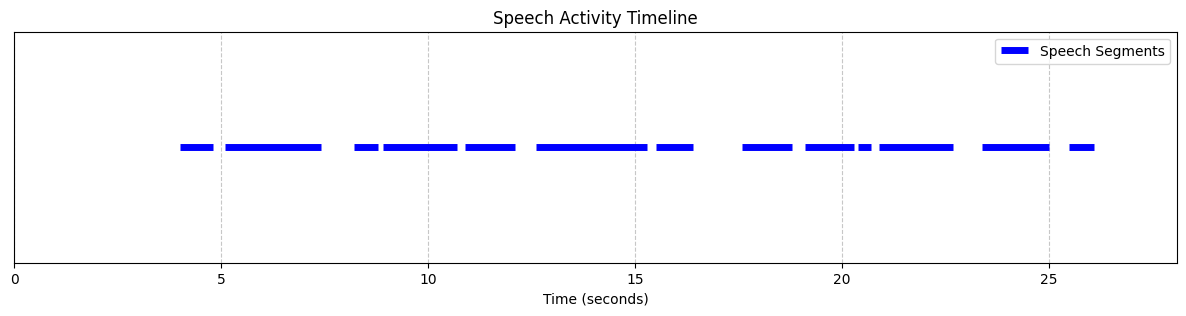

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 3))

for i, ts in enumerate(speech_timestamps):
    ax.hlines(y=0.5, xmin=ts['start'], xmax=ts['end'], linewidth=5, color='blue', label='Speech' if i == 0 else "")

ax.set_yticks([]) # Remove y-axis ticks as it's a single timeline
ax.set_xlabel('Time (seconds)')
ax.set_title('Speech Activity Timeline')
ax.set_xlim(0, max(ts['end'] for ts in speech_timestamps) + 2) # Adjust x-axis limit for better visualization
ax.legend(['Speech Segments'], loc='upper right')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

In [10]:
import torch
torch.set_num_threads(1)

model, utils = torch.hub.load(repo_or_dir='snakers4/silero-vad', model='silero_vad')
(get_speech_timestamps, _, read_audio, _, _) = utils

wav = read_audio('Recording.m4a')
speech_timestamps = get_speech_timestamps(
  wav,
  model,
  return_seconds=True,  # Return speech timestamps in seconds (default is samples)
)

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /root/.cache/torch/hub/master.zip


In [11]:
print(speech_timestamps)

[{'start': 4.0, 'end': 4.8}, {'start': 5.1, 'end': 7.4}, {'start': 8.2, 'end': 8.8}, {'start': 8.9, 'end': 10.7}, {'start': 10.9, 'end': 12.1}, {'start': 12.6, 'end': 15.3}, {'start': 15.5, 'end': 16.4}, {'start': 17.6, 'end': 18.8}, {'start': 19.1, 'end': 20.3}, {'start': 20.4, 'end': 20.7}, {'start': 20.9, 'end': 22.7}, {'start': 23.4, 'end': 25.0}, {'start': 25.5, 'end': 26.1}]
